In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc


In [20]:
# Load the dataset
# Replace "your_dataset.csv" with the path to your dataset
data = pd.read_csv(r"C:\Users\kalya\OneDrive\Documents\KAPIL_DATAanalysis\Capstone Project\Financial_Fraud_Detection_Datasets\cc_data.csv")
data


,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,1286992,17-06-2020 04:58,30546453310167,fraud_Jakubowski Group,food_dining,55.43,Nicholas,Tran,M,672 Randall Burg Suite 551,...,43.4512,-71.4890,7430,"Scientist, research (medical)",13-01-1955,b7d8dd8e9f941f316e5af3426dce91c0,1371445103,43.573310,-71.975075,0
388998,329380,06-06-2019 05:52,3562264947797240,fraud_Lockman Ltd,grocery_pos,111.77,Anthony,Velasquez,M,609 Hunt Grove,...,37.6047,-85.4251,301,"Research officer, political party",17-03-1967,6226318c59455a8a56dadf44307031b6,1338961944,38.538512,-84.999516,0
388999,950878,16-01-2020 13:20,4099707841315750,"fraud_Nicolas, Hills and McGlynn",entertainment,52.98,James,Stephens,M,1166 Castillo Mountains,...,38.2586,-78.4074,9815,"Designer, ceramics/pottery",07-07-1975,81287d23caeb5a07d0dd9ff7d61ddd9c,1358342419,38.423962,-78.882504,0
389000,958274,20-01-2020 08:51,676118385837,"fraud_Reichert, Huels and Hoppe",shopping_net,3.38,Katelyn,Wise,F,674 Maureen Summit Apt. 276,...,44.9897,-122.6187,1252,"Engineer, petroleum",06-02-1937,b78283119c244578ee42b7f0f7708496,1358671894,45.180731,-122.515971,0


In [21]:
# dropping index column
data=data.drop(columns='index')

In [22]:
# Task1: What are the dimensions (number of rows and columns) of the dataset? 
# Dimensions of the dataset

print("Dimensions (number of rows and columns) of the dataset:", data.shape)

Dimensions (number of rows and columns) of the dataset: (389002, 22)


In [23]:
# Task 2: How many unique values are there in each categorical variable?
# Unique values in each categorial variable

unique_values = data.select_dtypes(include=['object']).nunique()
print("Unique values in each categorical variable:")
print(unique_values)

Unique values in each categorical variable:
trans_date_trans_time    293627
merchant                    693
category                     14
first                       352
last                        481
gender                        2
street                      979
city                        890
state                        51
job                         492
dob                         964
trans_num                389002
dtype: int64


In [7]:
# Task 3: What is the distribution of numerical variables in the dataset? 
# Distribution of numerical variables

numerical_summary = data.describe()
print("Distribution of numerical variables:")
numerical_summary

Distribution of numerical variables:


,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,4.191512e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,1.800429e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,3.521417e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,4.642255e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,4.992346e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [24]:
# Task 4: Are there any missing values in the dataset?
# Missing values in the dataset

missing_values = data.isnull().sum()
print("Missing values in the dataset: ")
print(missing_values)

Missing values in the dataset: 
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [25]:
# Task 5:What are the summary statistics (mean, median, min, max, etc.) for numerical variables? 
# Summary statistic for numerical variables

summary_statistics = data.describe(include='all')
print("Summary statistic for numerical variables: ")
summary_statistics

Summary statistic for numerical variables: 


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,389002,3.890020e+05,389002,389002,389002.000000,389002,389002,389002,389002,389002,...,389002.000000,389002.000000,3.890020e+05,389002,389002,389002,3.890020e+05,389002.000000,389002.000000,389002.000000
unique,293627,NaN,693,14,NaN,352,481,2,979,890,...,NaN,NaN,NaN,492,964,389002,NaN,NaN,NaN,NaN
top,22-12-2019 18:12,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,1652 James Mews,Birmingham,...,NaN,NaN,NaN,Film/video editor,23-03-1977,326bf5da22f1a5ddd2a0be58d1684fac,NaN,NaN,NaN,NaN
freq,8,NaN,1305,39633,NaN,7982,8511,213231,980,1740,...,NaN,NaN,NaN,2945,1694,1,NaN,NaN,NaN,NaN
mean,NaN,4.191512e+17,NaN,NaN,70.442148,NaN,NaN,NaN,NaN,NaN,...,38.533121,-90.237664,8.868084e+04,NaN,NaN,NaN,1.349251e+09,38.531683,-90.236674,0.005789
std,NaN,1.311579e+18,NaN,NaN,162.203915,NaN,NaN,NaN,NaN,NaN,...,5.074596,13.745855,3.012101e+05,NaN,NaN,NaN,1.285085e+07,5.109400,13.757311,0.075866
min,NaN,6.041621e+10,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,20.027100,-165.672300,2.300000e+01,NaN,NaN,NaN,1.325376e+09,19.029798,-166.669638,0.000000
25%,NaN,1.800429e+14,NaN,NaN,9.660000,NaN,NaN,NaN,NaN,NaN,...,34.620500,-96.798000,7.430000e+02,NaN,NaN,NaN,1.338751e+09,34.719394,-96.905445,0.000000
50%,NaN,3.521417e+15,NaN,NaN,47.570000,NaN,NaN,NaN,NaN,NaN,...,39.354300,-87.476900,2.456000e+03,NaN,NaN,NaN,1.349267e+09,39.361065,-87.446843,0.000000
75%,NaN,4.642255e+15,NaN,NaN,83.077500,NaN,NaN,NaN,NaN,NaN,...,41.940400,-80.158000,2.032800e+04,NaN,NaN,NaN,1.359460e+09,41.956012,-80.253831,0.000000


Correlation between numerical varables: 


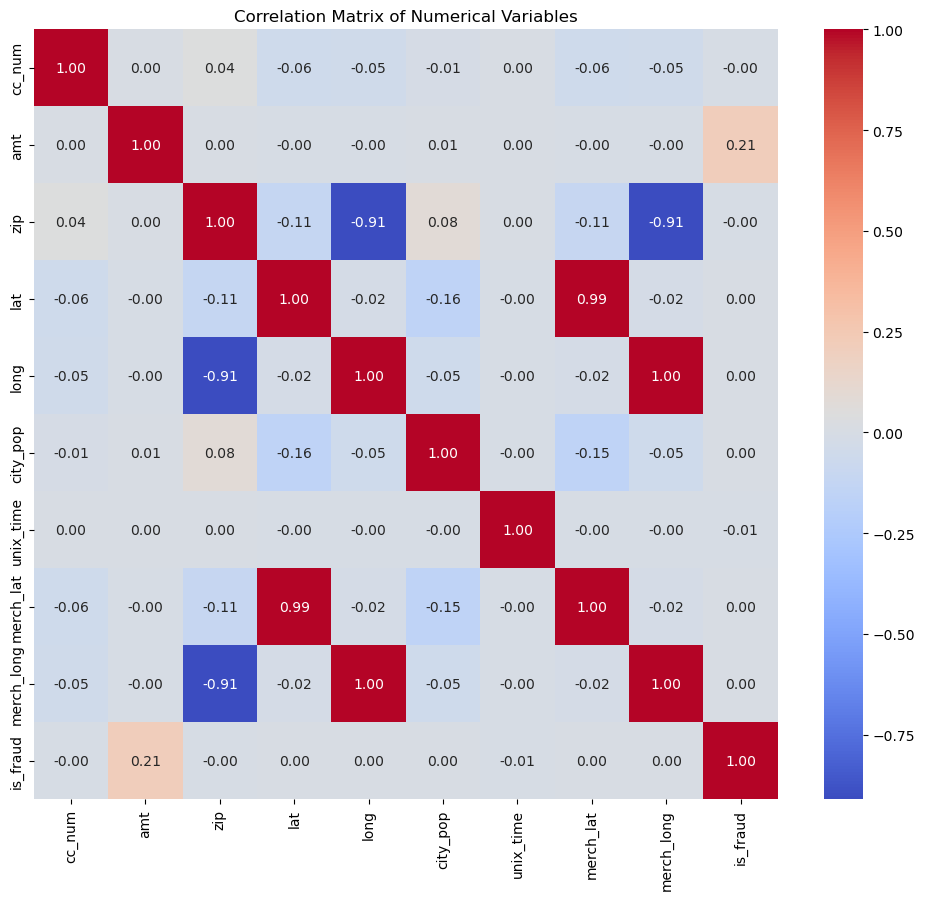

In [30]:
# Task 6: Is there any correlation between numerical variables? If so, how strong is the correlation?
# Correlation between numerical variables

correlation_matrix = data.select_dtypes([float,int]).corr()
print("Correlation between numerical varables: ")
correlation_matrix

####

# Visualize Correlation Matrix with a Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.savefig('correlation_heatmap_response.png')


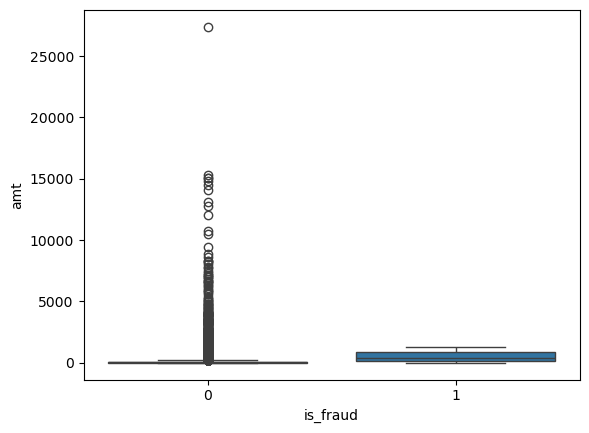

In [20]:
# Task 7: How does the distribution of an amt differ across is_fraud categories? 

sns.boxplot(x='is_fraud', y='amt', data=data)
plt.show()

Summary Statistics for Amount by Fraud Category:
             count        mean         std   min       25%      50%       75%  \
is_fraud                                                                        
0         386750.0   67.834157  156.227752  1.00    9.6200   47.330   82.5000   
1           2252.0  518.328677  389.127281  1.18  147.8825  365.285  888.3425   

               max  
is_fraud            
0         27390.12  
1          1294.83  


C:\Users\kalya\AppData\Local\Temp\ipykernel_10532\2043579554.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=data, palette='viridis')


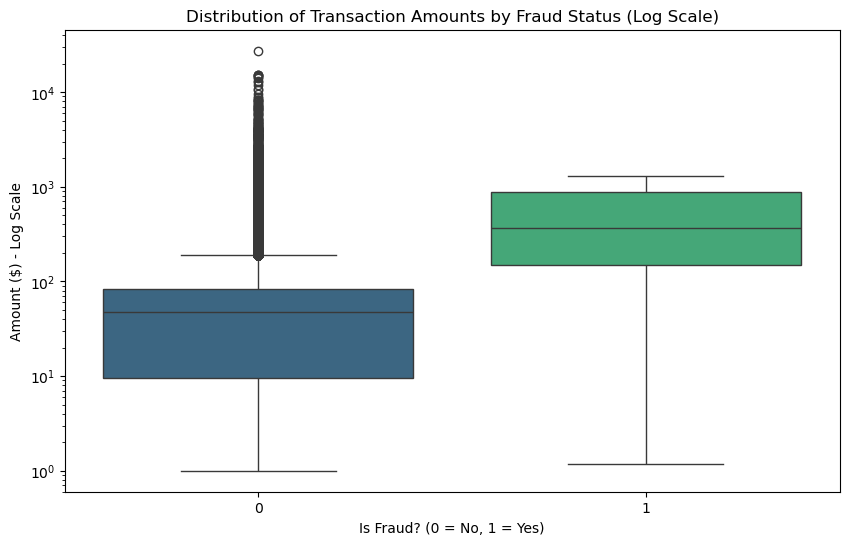

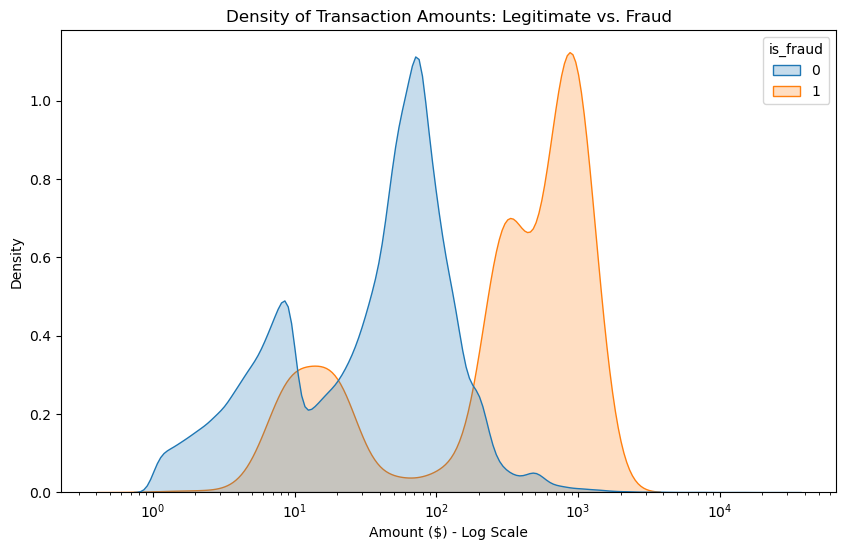

In [31]:
# 1. Statistical Summary by Category
# This gives a quick numeric comparison of Mean, Median (50%), and Max

print("Summary Statistics for Amount by Fraud Category:")
print(data.groupby('is_fraud')['amt'].describe())

# 2. Visualizing with a Boxplot (Log Scale)
# A boxplot helps identify if fraud transactions have a higher median or more outliers.
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=data, palette='viridis')
plt.yscale('log')  # Necessary due to extreme skewness (Max is 27,390 vs Median 47)
plt.title('Distribution of Transaction Amounts by Fraud Status (Log Scale)')
plt.xlabel('Is Fraud? (0 = No, 1 = Yes)')
plt.ylabel('Amount ($) - Log Scale')
plt.show()


# 3. Kernel Density Estimate (KDE) Plot
# This shows the "shape" of the distribution for both categories.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='amt', hue='is_fraud', common_norm=False, fill=True, log_scale=True)
plt.title('Density of Transaction Amounts: Legitimate vs. Fraud')
plt.xlabel('Amount ($) - Log Scale')
plt.show()


--- 'amt' Outlier Analysis ---
Anything above 193.20 is an outlier.
Number of 'amt' outliers: 20377
Percentage of dataset: 5.24%

--- 'city_pop' Outlier Analysis ---
Anything above 49705.50 is an outlier.
Number of 'city_pop' outliers: 72813
Percentage of dataset: 18.72%


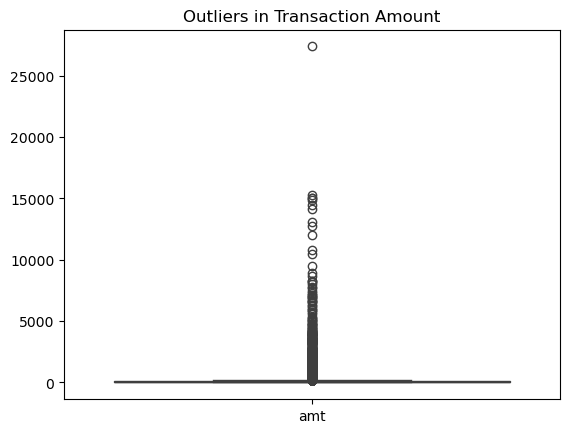

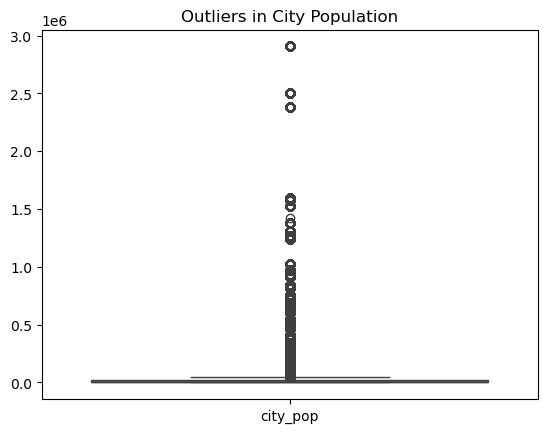

In [22]:
# Task 8: Are there any outliers in the city_pop and amt?  
# Outliers in numerical variables city_pop and amt

def find_outliers_iqr(data, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# 1. Detect outliers for 'amt'
amt_outliers, amt_lower, amt_upper = find_outliers_iqr(data, 'amt')
print(f"--- 'amt' Outlier Analysis ---")
print(f"Anything above {amt_upper:.2f} is an outlier.")
print(f"Number of 'amt' outliers: {len(amt_outliers)}")
print(f"Percentage of dataset: {(len(amt_outliers)/len(data))*100:.2f}%\n")

# 2. Detect outliers for 'city_pop'
pop_outliers, pop_lower, pop_upper = find_outliers_iqr(data, 'city_pop')
print(f"--- 'city_pop' Outlier Analysis ---")
print(f"Anything above {pop_upper:.2f} is an outlier.")
print(f"Number of 'city_pop' outliers: {len(pop_outliers)}")
print(f"Percentage of dataset: {(len(pop_outliers)/len(data))*100:.2f}%")


# The dots beyond the "whiskers" are your outliers

sns.boxplot(data=data[['amt']] )
plt.title('Outliers in Transaction Amount')
plt.show()

sns.boxplot(data=data[['city_pop']] )
plt.title('Outliers in City Population')
plt.show()


C:\Users\kalya\AppData\Local\Temp\ipykernel_10532\106297083.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = daily_trend.resample('M').sum()


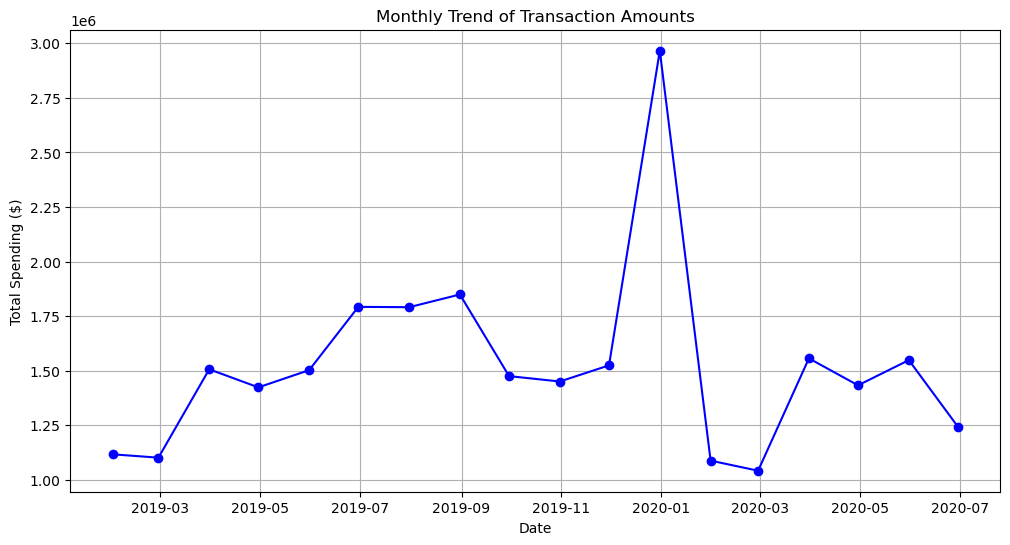

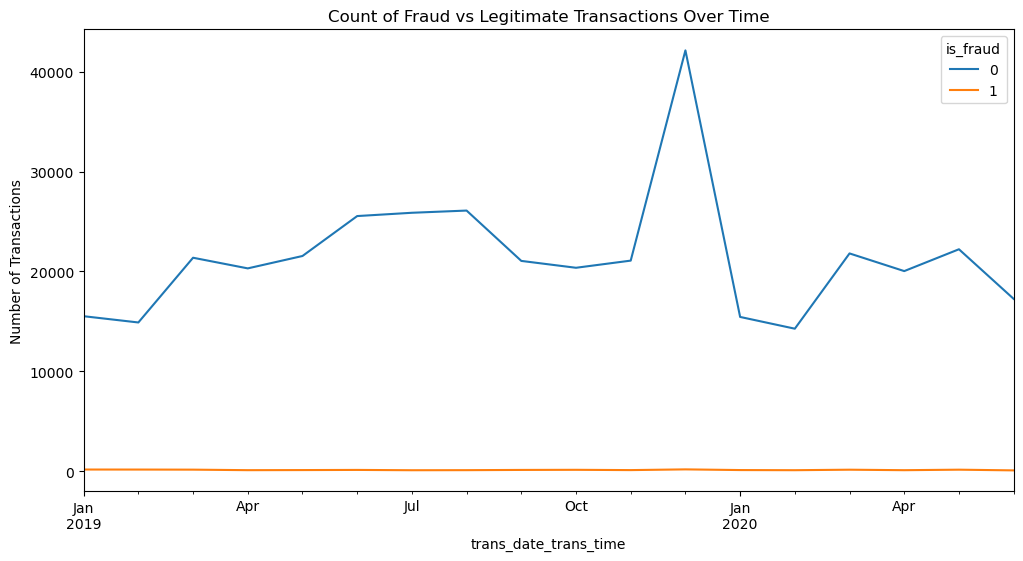

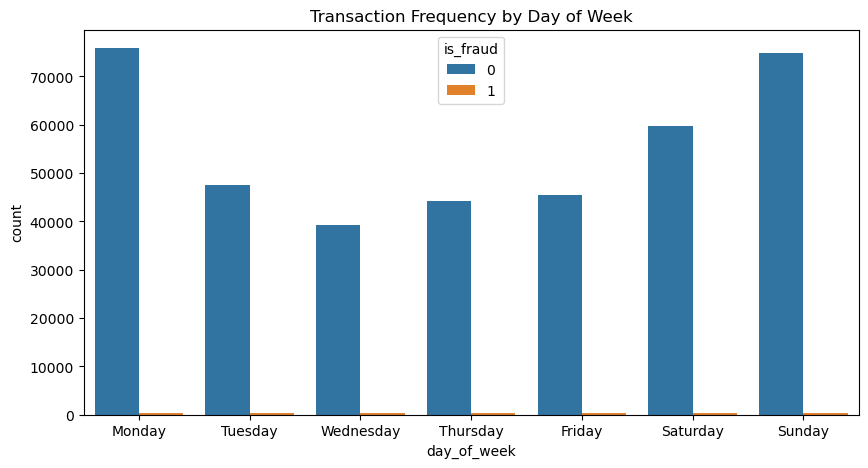

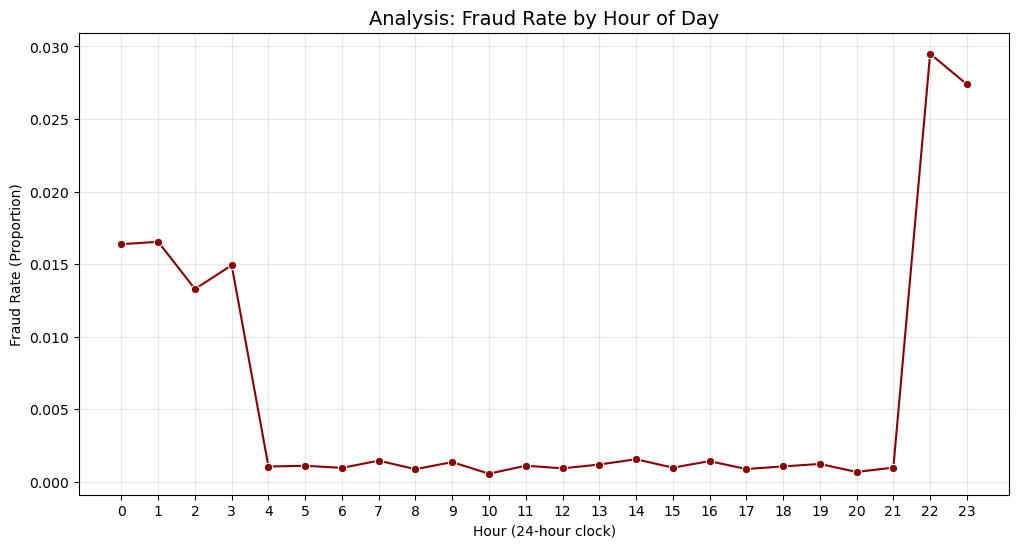

In [43]:
# Task 9: Are there any trends or patterns in the data over time (if applicable)
# This depends on the specific data you're working with. You can plot time-series data and look for trends.

# 1. Prepare the Date Column
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])

# 2. Daily Transaction Volume and Amount Trend
# We group by date and calculate the count of transactions and the total sum
daily_trend = data.groupby('trans_date_trans_time').agg({'amt': ['sum', 'count']})
daily_trend.columns = ['Total_Amount', 'Transaction_Count']

# 3. Visualizing Seasonality (Monthly Trends)
# Resampling by Month ('M') helps smooth out daily fluctuations
monthly_trend = daily_trend.resample('M').sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend['Total_Amount'], marker='o', color='b', linestyle='-')
plt.title('Monthly Trend of Transaction Amounts')
plt.xlabel('Date')
plt.ylabel('Total Spending ($)')
plt.grid(True)
plt.show()

# 4. Pattern Analysis: Fraud over Time
# Checking if fraud spikes during specific months or holidays
fraud_trend = data.groupby([data['trans_date_trans_time'].dt.to_period('M'), 'is_fraud']).size().unstack().fillna(0)

fraud_trend.plot(kind='line', figsize=(12, 6))
plt.title('Count of Fraud vs Legitimate Transactions Over Time')
plt.ylabel('Number of Transactions')
plt.show()

# 5. Pattern Analysis: Day of the Week
# Does fraud happen more on weekends?
data['day_of_week'] = data['trans_date_trans_time'].dt.day_name()
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='day_of_week', hue='is_fraud', 
              order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Transaction Frequency by Day of Week')
plt.show()

# 6. Extract the hour (0-23)
data['hour'] = data['trans_date_trans_time'].dt.hour

# 7. Calculate Fraud Rate
# The mean of a 0/1 column gives the percentage/rate of occurrences
fraud_rate_by_hour = data.groupby('hour')['is_fraud'].mean()

# 8. Visualize the results
plt.figure(figsize=(12, 6))
sns.lineplot(x=fraud_rate_by_hour.index, y=fraud_rate_by_hour.values, marker='o', color='darkred')

plt.title('Analysis: Fraud Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour (24-hour clock)')
plt.ylabel('Fraud Rate (Proportion)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\kalya\AppData\Local\Temp\ipykernel_10532\4082752242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_fraud.index, y=category_fraud.values, palette='Reds_r')


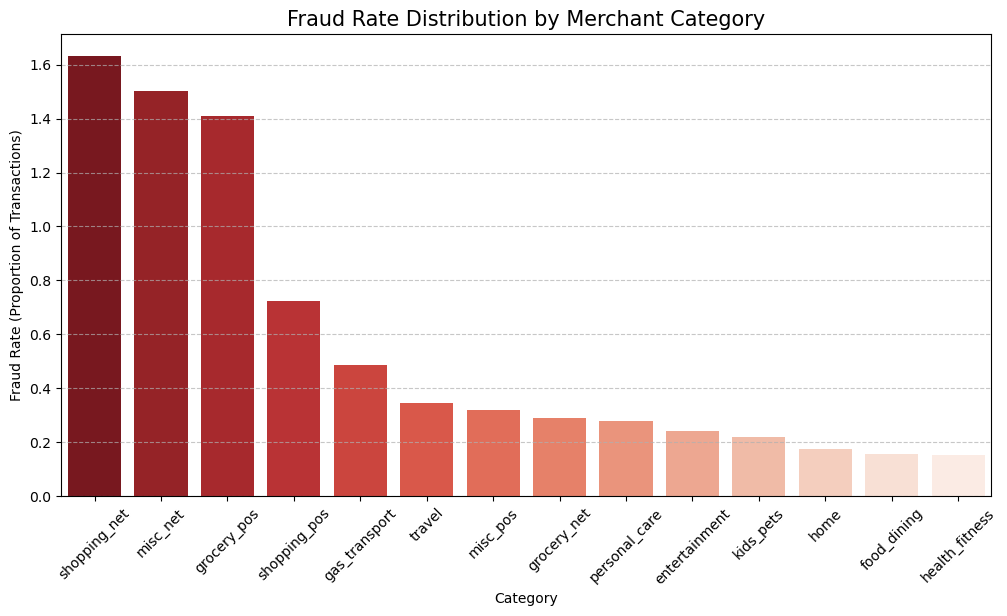

Fraud Rate (%) by Category:
category
shopping_net      1.631733
misc_net          1.501674
grocery_pos       1.409025
shopping_pos      0.722609
gas_transport     0.486968
travel            0.344460
misc_pos          0.320193
grocery_net       0.288892
personal_care     0.277646
entertainment     0.241804
kids_pets         0.218244
home              0.176166
food_dining       0.155153
health_fitness    0.151562
Name: is_fraud, dtype: float64


In [47]:
# Task 10: How does the target variable (if available) distribute across different categories

# 1. Distribution of Fraud by Transaction Category

#  Analyze Fraud Rate by Category
# Group by category and calculate the mean of is_fraud (0s and 1s)
category_fraud = data.groupby('category')['is_fraud'].mean().sort_values(ascending=False)*100

#  Create the Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=category_fraud.index, y=category_fraud.values, palette='Reds_r')

plt.title('Fraud Rate Distribution by Merchant Category', fontsize=15)
plt.ylabel('Fraud Rate (Proportion of Transactions)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calculating the Fraud Rate (%) per Category
# This is often more useful because some categories might have very few transactions 
# but a very high percentage of fraud.
#fraud_rate = data.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
print("Fraud Rate (%) by Category:")
print(category_fraud)

In [35]:
# Task 11: Are there any unusual or unexpected values in the dataset that require further investigation?

# 1. Investigate extreme Amount Outliers
# Using 3 Standard Deviations for extreme anomaly detection
amt_mean = data['amt'].mean()
amt_std = data['amt'].std()
extreme_tx = data[data['amt'] > (amt_mean + 3 * amt_std)]

print(f"Investigate {len(extreme_tx)} transactions significantly above the mean.")
print(f"Maximum value found: {data['amt'].max()}\n") # Should be 27390.12

# 2. Check for Potential Data Corruption (Scientific Notation Issues)
# In your preview, cc_num is in scientific notation (3.59E+15)
# This can sometimes cause loss of precision. Check for duplicated CC numbers.
duplicated_cc = data['cc_num'].duplicated().sum()
print(f"Number of duplicated credit card numbers: {duplicated_cc}\n")

# 3. Check for Unusual Population Data
# city_pop mode is 606, but max is 2.9 million
large_cities = data[data['city_pop'] > 1000000]['city'].unique()
print(f"Transactions originating from mega-cities: {large_cities}\n")

# 4. Check for 'Hidden' Nulls in Dates
# Preview shows #######, which might hide invalid dates
data['trans_date_check'] = pd.to_datetime(data['trans_date_trans_time'], errors='coerce')
invalid_dates = data['trans_date_check'].isna().sum()
print(f"Number of unparseable or invalid dates: {invalid_dates}")

# 5. Look for Negative Values (Unexpected for 'amt' or 'city_pop')
negative_amt = (data['amt'] < 0).sum()
negative_pop = (data['city_pop'] < 0).sum()
print(f"Negative amounts: {negative_amt},\n Negative populations: {negative_pop}")

Investigate 3718 transactions significantly above the mean.
Maximum value found: 27390.12

Number of duplicated credit card numbers: 388023

Transactions originating from mega-cities: ['Houston' 'San Antonio' 'Brooklyn' 'Phoenix' 'Dallas' 'Philadelphia'
 'New York City' 'Bronx' 'San Diego' 'Los Angeles' 'Minneapolis'
 'Las Vegas']

Number of unparseable or invalid dates: 0
Negative amounts: 0,
 Negative populations: 0


In [36]:
# Task 12: Are there any potential data entry errors or inconsistencies in the dataset? 
# 1. Check for Credit Card Precision Loss (Ending in 0000)
# If many cards end in '000', Excel likely rounded them.
precision_check = data[data['cc_num'].astype(str).str.contains('000$')]
print(f"Potential precision-loss errors in CC numbers: {len(precision_check)}")

# 2. Find "Impossible" Transactions
# Identifying transactions that are more than 100 standard deviations from the mean
extreme_outliers = data[data['amt'] > (data['amt'].mean() + 100 * data['amt'].std())]
print(f"Transactions to investigate for entry errors: {len(extreme_outliers)}")

# 3. Check for Date Logic Errors
# Check if Date of Birth (dob) is after the Transaction Date
data['dob'] = pd.to_datetime(data['dob'], errors='coerce')
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'], errors='coerce')
date_errors = data[data['dob'] > data['trans_date_trans_time']]
print(f"Records where DOB is after Transaction Date: {len(date_errors)}")

Potential precision-loss errors in CC numbers: 37996
Transactions to investigate for entry errors: 1
Records where DOB is after Transaction Date: 0


C:\Users\kalya\AppData\Local\Temp\ipykernel_10532\2726108426.py:14: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['dob'] = pd.to_datetime(data['dob'], errors='coerce')


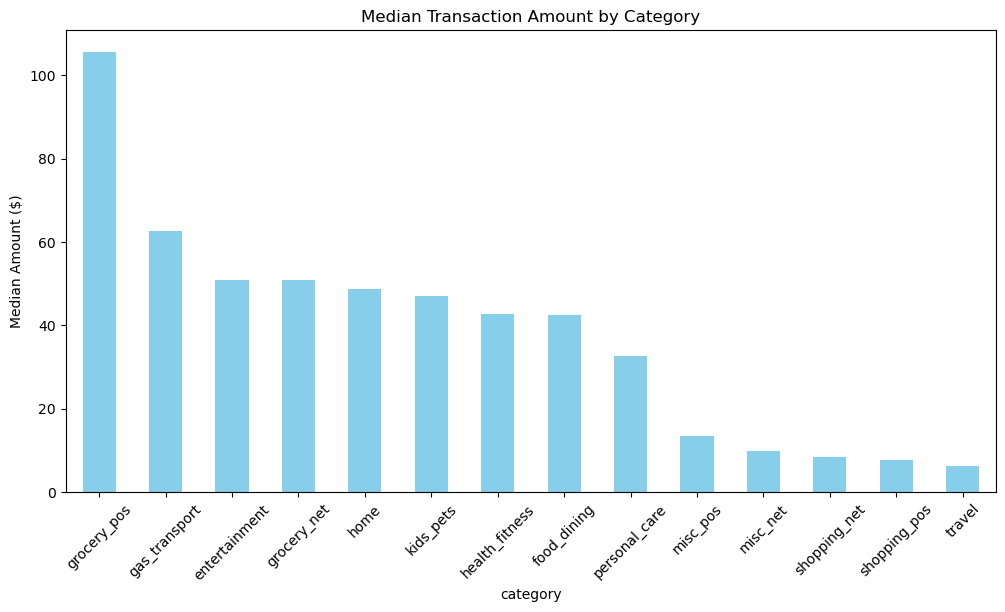

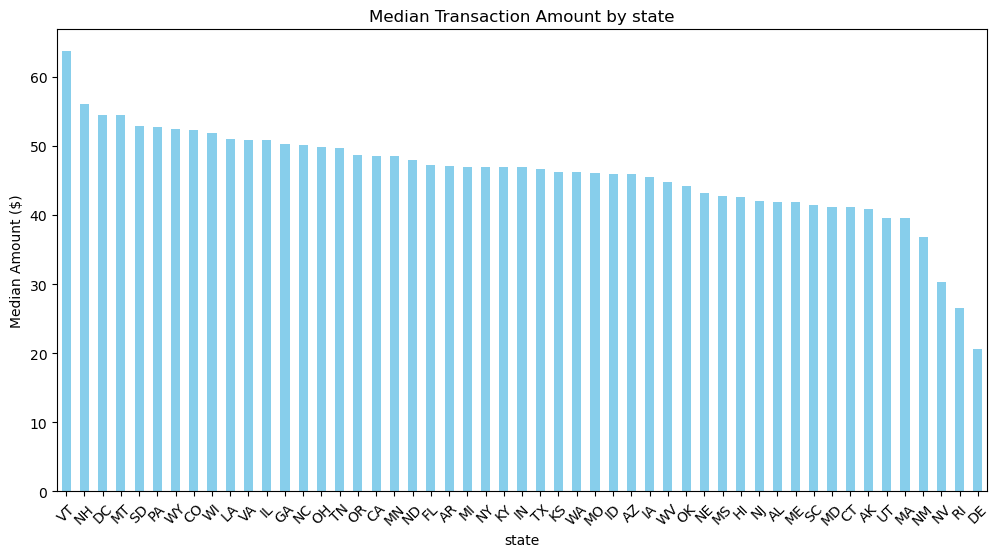

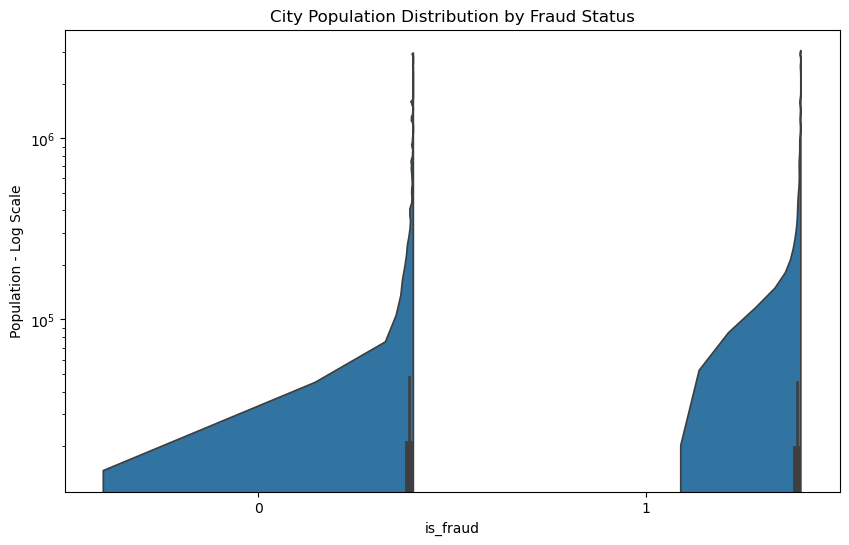

                               mean   median  count
category       is_fraud                            
entertainment  0          63.034833   50.740  28054
               1         500.513676  499.185     68
food_dining    0          51.091296   42.440  27028
               1         118.530476  117.700     42
gas_transport  0          63.649185   62.840  39440
               1          12.363472   10.720    193
grocery_net    0          53.821194   50.950  13806
               1          12.238000   12.325     40
grocery_pos    0         114.726910  104.940  36245
               1         313.456158  311.015    518
health_fitness 0          54.277813   42.890  25693
               1          20.183846   19.650     39
home           0          57.950541   48.550  36832
               1         251.946462  248.040     65
kids_pets      0          57.691239   47.240  33833
               1          17.258784   19.385     74
misc_net       0          71.209706    9.700  18825
            

In [37]:
# Task 13: How does the distribution of numerical variables vary between different groups or segments of the dataset?


#  Average 'amt' by 'category'
# This helps identify which spending categories have the highest average transactions.
cat_summary_c = data.groupby('category')['amt'].median().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
cat_summary_c.plot(kind='bar', color='skyblue')
plt.title('Median Transaction Amount by Category')
plt.ylabel('Median Amount ($)')
plt.xticks(rotation=45)
plt.show()

#  Average 'amt' by 'job'
# This helps identify which categories of jobs have the highest average transactions.
cat_summary_s = data.groupby('state')['amt'].median().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
cat_summary_s.plot(kind='bar', color='skyblue')
plt.title('Median Transaction Amount by state')
plt.ylabel('Median Amount ($)')
plt.xticks(rotation=45)
plt.show()

# 3. 'city_pop' distribution by 'is_fraud'
# Does fraud happen more in small towns (median pop 2,456) or big cities?
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='is_fraud', y='city_pop', split=True)
plt.yscale('log')
plt.title('City Population Distribution by Fraud Status')
plt.ylabel('Population - Log Scale')
plt.show()

# 4. Statistical Table Comparison
# Provides exact numbers for mean/median across groups
segment_stats = data.groupby(['category', 'is_fraud'])['amt'].agg(['mean', 'median', 'count'])
print(segment_stats)

segment_stats_s = data.groupby(['state', 'is_fraud'])['amt'].agg(['mean', 'median', 'count'])
print(segment_stats_s)

In [38]:


# 1. Convert date columns to datetime objects
# The format in your sheet is Day-Month-Year (e.g., 23-03-2019)
data['dob'] = pd.to_datetime(data['dob'])
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])

# 2. Calculate exact age at the time of transaction
# This finds the difference in days and divides by 365.25 to account for leap years
data['age'] = (data['trans_date_trans_time'] - data['dob']).dt.days // 365

# 3. Categorize into Age Groups
# We define bins for the age ranges and corresponding labels
bins = [0, 18, 30, 45, 60, 110]
labels = ['Minor', 'Young Adult', 'Adult', 'Senior Adult', 'Senior']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)

# 4. Review the results
print(data[['dob', 'trans_date_trans_time', 'age', 'age_group']].head())

# 5. Optional: Analyze Fraud Distribution by Age Group
fraud_rate_by_age = data.groupby('age_group')['is_fraud'].mean() * 100
print("\nFraud Rate (%) by Age Group:")
print(fraud_rate_by_age)

         dob trans_date_trans_time  age     age_group
0 1984-02-29   2019-03-23 03:06:00   35         Adult
1 1955-07-25   2020-05-10 11:28:00   64        Senior
2 1975-09-11   2019-01-07 13:31:00   43         Adult
3 1964-01-04   2020-01-30 18:49:00   56  Senior Adult
4 1966-01-21   2019-06-12 03:04:00   53  Senior Adult

Fraud Rate (%) by Age Group:
age_group
Minor           0.822511
Young Adult     0.565343
Adult           0.430233
Senior Adult    0.636763
Senior          0.743973
Name: is_fraud, dtype: float64


C:\Users\kalya\AppData\Local\Temp\ipykernel_10532\3847150121.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_age = data.groupby('age_group')['is_fraud'].mean() * 100


In [39]:
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare Features (X) and Target (y)
# We use numerical columns and encode categories
X = data[['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']]
y = data['is_fraud']


In [40]:
# 2. Train a quick model
model = RandomForestClassifier(n_estimators=100)
model.fit(X, y)





RandomForestClassifier()

In [41]:
# 3. Get Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

amt           0.419849
merch_long    0.162496
merch_lat     0.162187
city_pop      0.088316
long          0.083778
lat           0.083374
dtype: float64


Top Factors Influencing Fraud:
amt           0.419849
merch_long    0.162496
merch_lat     0.162187
city_pop      0.088316
long          0.083778
lat           0.083374
dtype: float64


<Axes: >

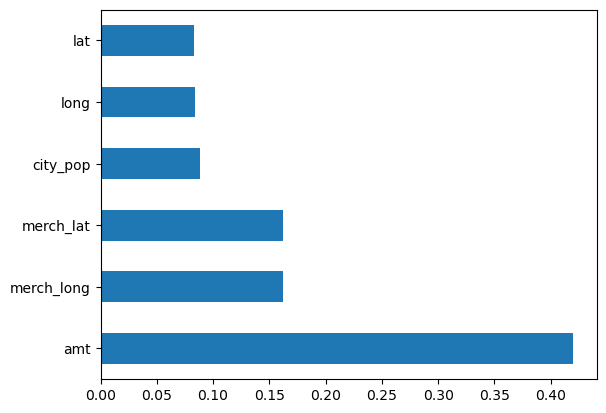

In [42]:
print("Top Factors Influencing Fraud:")
print(importance)

# Visualize the importance
importance.plot(kind='barh')